# DeBERTa-V3 Model

### Imports

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 36.6 MB/s eta 0:00:00


In [ ]:
from transformers import (
    DebertaV2Tokenizer,
    DebertaV2ForMaskedLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
    DebertaV2ForSequenceClassification,
    set_seed,
)
from datasets import load_dataset, Value
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
import optuna

### Set Seeds

In [ ]:
# For consistency in training
SEED = 42
set_seed(SEED)

### Pre-Training on Corpus

In [ ]:
# Loading model and tokenizer
import torch
# Force bfloat16 to avoid NaN issues with DeBERTa-v3 on some backends
deberta_model_mlm = DebertaV2ForMaskedLM.from_pretrained('microsoft/deberta-v3-base', torch_dtype=torch.bfloat16).to('cuda')
deberta_tokenizer = DebertaV2Tokenizer.from_pretrained('microsoft/deberta-v3-base')

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
DebertaV2ForMaskedLM LOAD REPORT from: microsoft/deberta-v3-base
Key                                           | Status     | 
----------------------------------------------+------------+-
lm_predictions.lm_head.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias                   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias             | UNEXPECTED | 
deberta.embeddings.position_embeddings.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias         | UNEXPECTED | 
cls.predictions.transform.dense.bias          | MISSING    | 
cls.predictions.transform.LayerNorm.bias      | MISSING    | 
cls.predictions.bias                          | MISSING    | 
cls.

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

In [ ]:
# Load dataset
pretrained_dataset = load_dataset('avanishd/ground-news-2026')
print(pretrained_dataset)

README.md:   0%|          | 0.00/679 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/395k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/375k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8642 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1884 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 1836
    })
})


In [ ]:
# Filter out any null summaries
pretrained_dataset = pretrained_dataset.filter(lambda dataset: dataset['summary'] != 'null' and dataset['summary'] is not None and dataset['summary'] != '')
print(pretrained_dataset)

Filter:   0%|          | 0/8642 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1884 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 1836
    })
})


In [ ]:
# Determines tokenization per data
def tokenize(data):
    return deberta_tokenizer(data['summary'], truncation=True, max_length=512, padding='max_length')

In [ ]:
# Example output of tokenizer
print(deberta_tokenizer("The father had two sons, the sons committed sins.", truncation=True, max_length=512, padding='max_length'))

{'input_ids': [279, 1503, 330, 375, 6579, 261, 262, 6579, 2484, 10096, 260, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
# Tokenizes the descriptions for DeBERTa training and remove unneccessary columns
tokenized_pretrained_dataset = pretrained_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'bias', 'headline', 'ground_news_interest_url'])
print(tokenized_pretrained_dataset)

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1836
    })
})


In [ ]:
# Used to mask random tokens
data_collator = DataCollatorForLanguageModeling(tokenizer=deberta_tokenizer, mlm=True, mlm_probability=0.15)

# Parameters used for trainer
training_args = TrainingArguments(
    output_dir='./domain-deberta-v3-mlm',
    save_steps=10000,
    eval_strategy="epoch",
    save_total_limit=2,
    logging_steps=500,
    num_train_epochs=15,
    per_device_train_batch_size=8,
    learning_rate=5e-5,
    bf16=True,
    fp16=False
)

trainer = Trainer(model=deberta_model_mlm,
                  args=training_args,
                  data_collator=data_collator,
                  train_dataset=tokenized_pretrained_dataset['train'],
                  eval_dataset=tokenized_pretrained_dataset['validation'])

In [ ]:
trainer.train() # Training

Epoch,Training Loss,Validation Loss
1,7.435175,6.679882
2,6.200958,5.757223
3,5.872773,5.449478
4,5.574745,5.196474
5,5.533917,5.168180
6,5.353840,5.034033
7,5.284959,5.050344
8,5.304780,4.947638
9,5.233215,4.943627
10,5.275103,4.941363


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=16215, training_loss=5.574107904284228, metrics={'train_runtime': 3578.0635, 'train_samples_per_second': 36.229, 'train_steps_per_second': 4.532, 'total_flos': 3.415870939336704e+16, 'train_loss': 5.574107904284228, 'epoch': 15.0})

In [ ]:
train_losses = [x['loss'] for x in trainer.state.log_history if 'loss' in x]
eval_losses = [x["eval_loss"] for x in trainer.state.log_history if "eval_loss" in x]

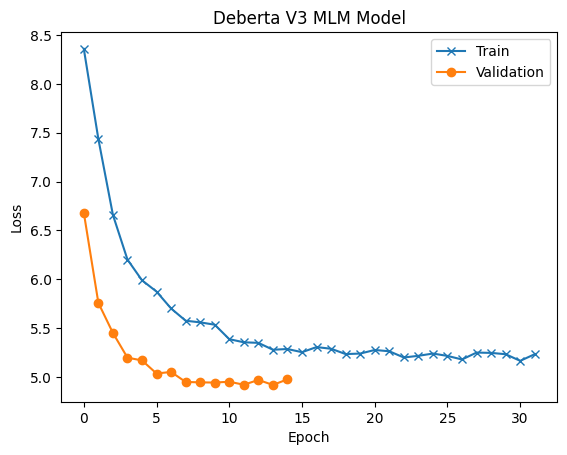

In [ ]:
plt.plot(train_losses, label="Train", marker="x")
plt.plot(eval_losses, label="Validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Deberta V3 MLM Model")
plt.show()

In [ ]:
# Saving model
deberta_model_mlm.save_pretrained('./domain-deberta-v3-mlm')
deberta_tokenizer.save_pretrained('./domain-deberta-v3-mlm')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./domain-deberta-v3-mlm/tokenizer_config.json',
 './domain-deberta-v3-mlm/tokenizer.json')

### Data Preprocessing for Classification

In [ ]:
# Load dataset
classifier_dataset = load_dataset('avanishd/ground-news-2026')

In [ ]:
# Filter out any null summaries
classifier_dataset = classifier_dataset.filter(lambda dataset: dataset['summary'] != 'null' and dataset['summary'] is not None and dataset['summary'] != '')

### Train for Classification (With Base Model)

In [ ]:
# IMPORTANT, reassign roberta_tokenizer so tokenize function uses the correct tokenizer
deberta_tokenizer = DebertaV2Tokenizer.from_pretrained('microsoft/deberta-v3-base')

In [ ]:
# Tokenizes the descriptions for RoBERTa training
tokenized_classifier_dataset_base = classifier_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'headline', 'ground_news_interest_url'])

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

In [ ]:
# Rename column from bias to labels
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.rename_column('bias', 'labels')

# Map label strings to integers
label_map = {"Far Left": 0, "Left": 1, "Lean Left": 2, "Center": 3, "Lean Right": 4, "Right": 5, "Far Right": 6}
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.map(lambda dataset: {'labels': int(label_map[dataset['labels']])})
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.cast_column('labels', Value('int32'))

print(tokenized_classifier_dataset_base)
print(tokenized_classifier_dataset_base['train']['labels'])

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8642 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1884 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1836
    })
})
Column([2, 1, 1, 1, 1])


In [ ]:
# Trial Evaluation Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "mae": mean_absolute_error(labels, preds),
    }

In [ ]:
def deberta_base_objective(trial):
    total_steps = len(tokenized_classifier_dataset_base['train'])

    learning_rate = trial.suggest_float("learning_rate", low=1e-6, high=5e-5, log=True)
    per_device_train_batch_size = trial.suggest_categorical("per_device_batch_size", [8, 16, 32])
    num_train_epochs = trial.suggest_int("num_train_epochs", low=1, high=7)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.3)
    warmup_steps = trial.suggest_float("warmup_steps", 0.0, int(total_steps * 0.2))
    label_smoothing_factor = trial.suggest_float("label_smoothing_factor", 0.0, 0.2)

    # Reload fresh model per trial
    model = DebertaV2ForSequenceClassification.from_pretrained('microsoft/deberta-v3-base', num_labels=7).to('cuda')

    # Parameters used for trainer
    training_args = TrainingArguments(
            output_dir=f'./domain-deberta-v3-classifier-base-trial-{trial.number}',
            save_strategy='epoch',
            eval_strategy='epoch',
            logging_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1_macro',
            greater_is_better=True,
            num_train_epochs=num_train_epochs,
            per_device_train_batch_size=per_device_train_batch_size,
            per_device_eval_batch_size=64,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            warmup_steps=warmup_steps,
            label_smoothing_factor=label_smoothing_factor,
            report_to='none',
            bf16=True,
            fp16=False
        )

    trainer = Trainer(model=model,
                  args=training_args,
                  train_dataset=tokenized_classifier_dataset_base['train'],
                  eval_dataset=tokenized_classifier_dataset_base['validation'],
                  compute_metrics=compute_metrics)

    trainer.train()

    eval_result = trainer.evaluate()
    return eval_result["eval_f1_macro"]

In [ ]:
deberta_base_study = optuna.create_study(
    direction="maximize",
    study_name="deberta_v3_base",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2),
)

[I 2026-03-15 23:53:14,183] A new study created in memory with name: deberta_v3_base


In [ ]:
deberta_base_study.optimize(deberta_base_objective, n_trials=2)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias          

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.894727,1.945613,0.136166,0.055962,1.552288
2,1.930147,1.912316,0.223312,0.052156,1.494553
3,1.906020,1.928332,0.223312,0.052156,1.494553
4,1.897373,1.915493,0.223312,0.052156,1.494553
5,1.894699,1.914776,0.223312,0.052156,1.494553
6,1.895115,1.919587,0.223312,0.052156,1.494553


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

[I 2026-03-16 00:18:09,155] Trial 1 finished with value: 0.05215621422210914 and parameters: {'learning_rate': 4.221395827133567e-06, 'per_device_batch_size': 16, 'num_train_epochs': 5, 'weight_decay': 0.09977718705122599, 'warmup_steps': 1484.3072517003945, 'label_smoothing_factor': 0.0999277352272086}. Best is trial 0 with value: 0.05215621422210914.


In [ ]:
# Get best hyper parameters from optuna trial to use in actual training
print(f"Best F1: {deberta_base_study.best_trial.value:.4f}")
print(f"Best params: {deberta_base_study.best_trial.params}")

Best F1: 0.0522
Best params: {'learning_rate': 2.5254025171689938e-06, 'per_device_batch_size': 32, 'num_train_epochs': 6, 'weight_decay': 0.29970051893227423, 'warmup_steps': 1640.9559063369438, 'label_smoothing_factor': 0.16926936889268285}


In [ ]:
# Load base model
deberta_model_classifier_with_base = DebertaV2ForSequenceClassification.from_pretrained('microsoft/deberta-v3-base', num_labels=7).to('cuda')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias          

In [ ]:
# Parameters used for trainer - Automatically using best params from study
best_params = deberta_base_study.best_trial.params

training_args_base = TrainingArguments(
        output_dir='./domain-deberta-v3-classifier-base',
        save_strategy='epoch',
        eval_strategy='epoch',
        logging_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        num_train_epochs=best_params['num_train_epochs'],
        per_device_train_batch_size=best_params['per_device_batch_size'],
        per_device_eval_batch_size=64,
        learning_rate=best_params['learning_rate'],
        weight_decay=best_params['weight_decay'],
        warmup_steps=best_params['warmup_steps'],
        label_smoothing_factor=best_params['label_smoothing_factor'],
        bf16=True,
        fp16=False
    )

trainer_base = Trainer(model=deberta_model_classifier_with_base,
                args=training_args_base,
                train_dataset=tokenized_classifier_dataset_base['train'],
                eval_dataset=tokenized_classifier_dataset_base['validation'],
                compute_metrics=compute_metrics)

In [ ]:
trainer_base.train() # Training

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.835817,1.559240,0.442810,0.301853,1.219499
2,1.877671,1.916931,0.223312,0.052156,1.494553
3,1.917515,1.919475,0.223312,0.052156,1.494553
4,1.915858,1.919260,0.223312,0.052156,1.494553
5,1.916539,1.916301,0.223312,0.052156,1.494553
6,1.914198,1.915007,0.223312,0.052156,1.494553


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1626, training_loss=1.8962664351985317, metrics={'train_runtime': 785.1258, 'train_samples_per_second': 66.043, 'train_steps_per_second': 2.071, 'total_flos': 1.3643691578486784e+16, 'train_loss': 1.8962664351985317, 'epoch': 6.0})

In [ ]:
# Saving model
deberta_model_classifier_with_base.save_pretrained('./domain-deberta-v3-classifier-base')
deberta_tokenizer.save_pretrained('./domain-deberta-v3-classifier-base')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./domain-deberta-v3-classifier-base/tokenizer_config.json',
 './domain-deberta-v3-classifier-base/tokenizer.json')

### Evaluation

In [ ]:
train_losses = [x['loss'] for x in trainer_base.state.log_history if 'loss' in x]
eval_losses = [x["eval_loss"] for x in trainer_base.state.log_history if "eval_loss" in x]

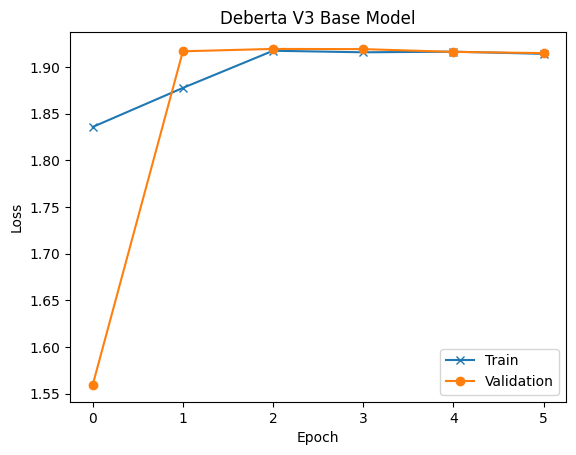

In [ ]:
plt.plot(train_losses, label="Train", marker="x")
plt.plot(eval_losses, label="Validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Deberta V3 Base Model")
plt.show()

In [ ]:
# List of label names
label_names = ["Far Left", "Left", "Lean Left", "Center", "Lean Right", "Right", "Far Right"]

# Metric function, that will produce all needed metrics
def metric_runner(model: Trainer, data):
    predictions = model.predict(data['test'])
    preds = np.argmax(predictions.predictions, axis=-1)
    true_labels = predictions.label_ids

    print(f"Mean Absolule Error: {mean_absolute_error(true_labels, preds)}")
    print()
    print(classification_report(true_labels, preds, target_names=label_names))

    cm = confusion_matrix(true_labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot()
    plt.show()

Mean Absolule Error: 1.4203821656050954

              precision    recall  f1-score   support

    Far Left       0.00      0.00      0.00       166
        Left       0.00      0.00      0.00       231
   Lean Left       0.00      0.00      0.00       260
      Center       0.21      1.00      0.34       388
  Lean Right       0.00      0.00      0.00       393
       Right       0.00      0.00      0.00       275
   Far Right       0.00      0.00      0.00       171

    accuracy                           0.21      1884
   macro avg       0.03      0.14      0.05      1884
weighted avg       0.04      0.21      0.07      1884



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


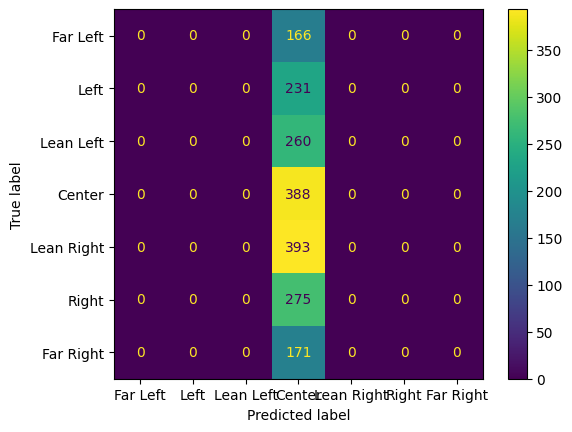

In [ ]:
metric_runner(trainer_base, tokenized_classifier_dataset_base) # Get metrics and evaluation

### Train for Classification (With Pretrained Model)

In [ ]:
# IMPORTANT, reassign deberta_tokenizer so tokenize function uses the correct tokenizer
deberta_tokenizer = DebertaV2Tokenizer.from_pretrained('./domain-deberta-v3-mlm')

In [ ]:
# Tokenizes the descriptions for DeBERTa training
tokenized_classifier_dataset_pretrained = classifier_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'headline', 'ground_news_interest_url'])

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

In [ ]:
# Rename column from bias to labels
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.rename_column('bias', 'labels')

# Map label strings to integers
label_map = {"Far Left": 0, "Left": 1, "Lean Left": 2, "Center": 3, "Lean Right": 4, "Right": 5, "Far Right": 6}
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.map(lambda dataset: {'labels': int(label_map[dataset['labels']])})
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.cast_column('labels', Value('int32'))

print(tokenized_classifier_dataset_pretrained)
print(tokenized_classifier_dataset_pretrained['train']['labels'])

Map:   0%|          | 0/8642 [00:00<?, ? examples/s]

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8642 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1884 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1836 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8642
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1884
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1836
    })
})
Column([2, 1, 1, 1, 1])


In [ ]:
def deberta_pretrained_objective(trial):
    total_steps = len(tokenized_classifier_dataset_pretrained['train'])

    learning_rate = trial.suggest_float("learning_rate", low=1e-6, high=5e-5, log=True)
    per_device_train_batch_size = trial.suggest_categorical("per_device_batch_size", [8, 16, 32])
    num_train_epochs = trial.suggest_int("num_train_epochs", low=1, high=7)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.3)
    warmup_steps = trial.suggest_float("warmup_steps", 0.0, int(total_steps * 0.2))
    label_smoothing_factor = trial.suggest_float("label_smoothing_factor", 0.0, 0.2)

    # Reload fresh model per trial
    model = DebertaV2ForSequenceClassification.from_pretrained('./domain-deberta-v3-mlm', num_labels=7).to('cuda')

    # Parameters used for trainer
    training_args = TrainingArguments(
            output_dir=f'./domain-deberta-v3-classifier-pretrained-trial-{trial.number}',
            save_strategy='epoch',
            eval_strategy='epoch',
            logging_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1_macro',
            greater_is_better=True,
            num_train_epochs=num_train_epochs,
            per_device_train_batch_size=per_device_train_batch_size,
            per_device_eval_batch_size=64,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            warmup_steps=warmup_steps,
            label_smoothing_factor=label_smoothing_factor,
            report_to='none',
            bf16=True,
            fp16=False
        )

    trainer = Trainer(model=model,
                  args=training_args,
                  train_dataset=tokenized_classifier_dataset_pretrained['train'],
                  eval_dataset=tokenized_classifier_dataset_pretrained['validation'],
                  compute_metrics=compute_metrics)

    trainer.train()

    eval_result = trainer.evaluate()
    return eval_result["eval_f1_macro"]

In [ ]:
deberta_pretrained_study = optuna.create_study(
    direction="maximize",
    study_name="deberta_v3_pretrained",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2),
)

[I 2026-03-16 00:31:34,086] A new study created in memory with name: deberta_v3_pretrained


In [ ]:
deberta_pretrained_study.optimize(deberta_pretrained_objective, n_trials=2)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: ./domain-deberta-v3-mlm
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.979470,1.979071,0.095861,0.074840,2.523420


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.938468,1.934486,0.177560,0.091095,1.588235
2,1.935837,1.930827,0.180828,0.095511,1.567538


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

[I 2026-03-16 00:38:50,893] Trial 1 finished with value: 0.09551075719420495 and parameters: {'learning_rate': 3.2933215771023297e-06, 'per_device_batch_size': 16, 'num_train_epochs': 2, 'weight_decay': 0.17704753246834334, 'warmup_steps': 1379.8288585193845, 'label_smoothing_factor': 0.15790382846465345}. Best is trial 1 with value: 0.09551075719420495.


In [ ]:
# Check a batch of tokenized data to ensure input_ids and labels are correctly formed
batch = data_collator([tokenized_pretrained_dataset['train'][i] for i in range(2)])
print("Input IDs shape:", batch['input_ids'].shape)
print("Labels shape:", batch['labels'].shape)

# Check how many tokens are actually masked
masked_tokens = (batch['labels'] != -100).sum().item()
total_tokens = batch['labels'].numel()
print(f"Masked tokens: {masked_tokens} / {total_tokens} ({masked_tokens/total_tokens:.2%})")

Input IDs shape: torch.Size([2, 512])
Labels shape: torch.Size([2, 512])
Masked tokens: 5 / 1024 (0.49%)


In [ ]:
# Get best hyper parameters from optuna trial to use in actual training
print(f"Best F1: {deberta_base_study.best_trial.value:.4f}")
print(f"Best params: {deberta_base_study.best_trial.params}")

Best F1: 0.0522
Best params: {'learning_rate': 2.5254025171689938e-06, 'per_device_batch_size': 32, 'num_train_epochs': 6, 'weight_decay': 0.29970051893227423, 'warmup_steps': 1640.9559063369438, 'label_smoothing_factor': 0.16926936889268285}


In [ ]:
# Load base model
deberta_model_classifier_with_pretrained = DebertaV2ForSequenceClassification.from_pretrained('./domain-deberta-v3-mlm', num_labels=7).to('cuda')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: ./domain-deberta-v3-mlm
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Parameters used for trainer - Automatically using best params from study
best_params_pre = deberta_pretrained_study.best_trial.params

training_args_pretrained = TrainingArguments(
        output_dir='./domain-deberta-v3-classifier-pretrained',
        save_strategy='epoch',
        eval_strategy='epoch',
        logging_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        num_train_epochs=best_params_pre['num_train_epochs'],
        per_device_train_batch_size=best_params_pre['per_device_batch_size'],
        per_device_eval_batch_size=64,
        learning_rate=best_params_pre['learning_rate'],
        weight_decay=best_params_pre['weight_decay'],
        warmup_steps=best_params_pre['warmup_steps'],
        label_smoothing_factor=best_params_pre['label_smoothing_factor'],
        bf16=True,
        fp16=False
    )

trainer_pretrained = Trainer(model=deberta_model_classifier_with_pretrained,
                args=training_args_pretrained,
                train_dataset=tokenized_classifier_dataset_pretrained['train'],
                eval_dataset=tokenized_classifier_dataset_pretrained['validation'],
                compute_metrics=compute_metrics)

In [ ]:
trainer_pretrained.train() # Training

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Mae
1,1.988723,1.986557,0.096950,0.062519,2.613290
2,1.982166,1.976938,0.102397,0.073482,2.506536


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1082, training_loss=1.9854442998353743, metrics={'train_runtime': 272.203, 'train_samples_per_second': 63.497, 'train_steps_per_second': 3.975, 'total_flos': 4547897192828928.0, 'train_loss': 1.9854442998353743, 'epoch': 2.0})

In [ ]:
# Saving model
deberta_model_classifier_with_pretrained.save_pretrained('./domain-deberta-v3-classifier-pretrained')
deberta_tokenizer.save_pretrained('./domain-deberta-v3-classifier-pretrained')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./domain-deberta-v3-classifier-pretrained/tokenizer_config.json',
 './domain-deberta-v3-classifier-pretrained/tokenizer.json')

### Evaluation

In [ ]:
train_losses = [x['loss'] for x in trainer_pretrained.state.log_history if 'loss' in x]
eval_losses = [x["eval_loss"] for x in trainer_pretrained.state.log_history if "eval_loss" in x]

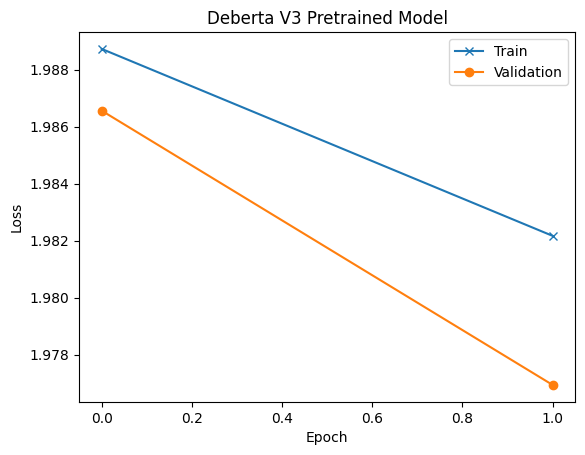

In [ ]:
plt.plot(train_losses, label="Train", marker="x")
plt.plot(eval_losses, label="Validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Deberta V3 Pretrained Model")
plt.show()

Mean Absolule Error: 2.5329087048832273

              precision    recall  f1-score   support

    Far Left       0.10      0.01      0.02       166
        Left       0.00      0.00      0.00       231
   Lean Left       0.14      0.13      0.14       260
      Center       0.13      0.01      0.01       388
  Lean Right       0.10      0.00      0.00       393
       Right       0.16      0.27      0.20       275
   Far Right       0.07      0.46      0.12       171

    accuracy                           0.10      1884
   macro avg       0.10      0.12      0.07      1884
weighted avg       0.11      0.10      0.07      1884



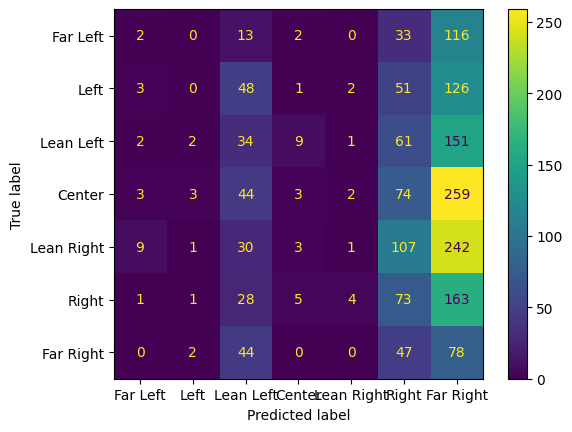

In [ ]:
metric_runner(trainer_pretrained, tokenized_classifier_dataset_pretrained) # Get metrics and evaluation

### Check Significance of Results with Bootstrapping

In [ ]:
def bootstrap_f1(y_true, y_pred_a, y_pred_b, n_boot=10000):
    rng = np.random.RandomState(42)
    n = len(y_true)
    boot_diffs = []

    a_score = f1_score(y_true, y_pred_a, average='macro')
    b_score = f1_score(y_true, y_pred_b, average='macro')
    score_diff = a_score - b_score

    for _ in range(n_boot):
        idex_list = rng.randint(0, n, size=n)

        f1_a = f1_score(y_true[idex_list], y_pred_a[idex_list], average="macro")
        f1_b = f1_score(y_true[idex_list], y_pred_b[idex_list], average="macro")

        boot_diffs.append(f1_a - f1_b)

    boot_diffs = np.array(boot_diffs)
    p_value = np.mean(boot_diffs <= 0)

    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)

    print("F1 Score A: ", a_score)
    print("F1 Score B: ", b_score)
    print("F1 Score Difference: ", score_diff)
    print("CI Lower: ", ci_lower)
    print("CI Upper: ", ci_upper)
    print("P Value: ", p_value)
    print("Significant: ", 0.0 < ci_lower or ci_upper < 0.0)

In [ ]:
base_trainer = Trainer(DebertaV2ForSequenceClassification.from_pretrained('./domain-deberta-v3-classifier-base'))
pretrained_trainer = Trainer(DebertaV2ForSequenceClassification.from_pretrained('./domain-deberta-v3-classifier-pretrained'))

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [ ]:
base_predictions = base_trainer.predict(tokenized_classifier_dataset_base['test'])
base_preds = np.argmax(base_predictions.predictions, axis=-1)
true_labels = base_predictions.label_ids

pretrained_predictions = pretrained_trainer.predict(tokenized_classifier_dataset_pretrained['test'])
pretrained_preds = np.argmax(pretrained_predictions.predictions, axis=-1)

In [ ]:
bootstrap_f1(true_labels, base_preds, pretrained_preds)

F1 Score A:  0.04879275653923541
F1 Score B:  0.0697561128995245
F1 Score Difference:  -0.020963356360289093
CI Lower:  -0.03194534127992185
CI Upper:  -0.010121967220490042
P Value:  0.9999
Significant:  True


### Upload the better model

Upload the model that boostrapping shows is better. We have always observed a statistically significant difference.

In [ ]:
from google.colab import userdata
from huggingface_hub import login

# Retrieve token and login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

# Push the base model and tokenizer to Hugging face
deberta_model_classifier_with_pretrained.push_to_hub("avanishd/deberta-v3-pretrained-ground-news")
deberta_tokenizer.push_to_hub("avanishd/deberta-v3-pretrained-ground-news")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...010v5sn/model.safetensors:  11%|#         | 40.0MB /  369MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/avanishd/deberta-v3-pretrained-ground-news/commit/c0840404e0cc2d3a63a9d7808ea0c7135288e103', commit_message='Upload tokenizer', commit_description='', oid='c0840404e0cc2d3a63a9d7808ea0c7135288e103', pr_url=None, repo_url=RepoUrl('https://huggingface.co/avanishd/deberta-v3-pretrained-ground-news', endpoint='https://huggingface.co', repo_type='model', repo_id='avanishd/deberta-v3-pretrained-ground-news'), pr_revision=None, pr_num=None)